In [18]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.optimize import brentq

# log10 K of each dissociation reaction at 25 C  (TOUGHREACT / EQ3-6 database)
lk = dict(co2=-6.345, co3=10.329, oh=13.995,
          cacl=0.696, caco3=7.002, cahco3=-1.047, caoh=12.850,
          mgcl=0.135, mgco3=7.350, mghco3=-1.036, mgoh=11.785,
          nacl=0.777, naco3=9.815, nahco3=-0.154, naoh=14.180)

# open system: CO2(aq) fixed by atmospheric pCO2 and the database Henry constant
pCO2   = 10**-3.5                 # atmospheric CO2 partial pressure (atm)
logKH  = -1.469                   # CO2(g) = CO2(aq)
aCO2   = 10**logKH * pCO2         # {CO2(aq)} activity = 10^-4.97

A_DAVIES = 0.509                  # Debye-Huckel constant at 25 C
DAVIES_B = 0.5                    # Davies coefficient
MM = dict(Ca=40.078, Mg=24.305, Na=22.99, Cl=35.45, CO3=60.008, HCO3=61.016)

# surface density 0.76 m2/g (mean diameter 2.8 um, density 2850 kg/m3), 60 g/L loading
St = 45.3                         # m2 / L of reactor C

In [19]:
def gammas(I):
    if I <= 0:
        return 1.0, 1.0, 1.0
    f = -A_DAVIES * (np.sqrt(I)/(1+np.sqrt(I)) - DAVIES_B*I)
    return 10**f, 10**(4*f), 1.0     # gamma1 (z=1), gamma2 (z=2), gamma0 (neutral = 1)



## Law mass balance equations
```
Ca_T = [Ca²⁺] + [CaCl⁺] + [CaCO₃] + [CaHCO₃⁺] + [CaOH⁺]
Mg_T = [Mg²⁺] + [MgCl⁺] + [MgCO₃] + [MgHCO₃⁺] + [MgOH⁺]
Na_T = [Na⁺]  + [NaCl]   + [NaCO₃⁻] + [NaHCO₃] + [NaOH]
Cl_T = [Cl⁻]  + [CaCl⁺] + [MgCl⁺] + [NaCl]
```


In [20]:
def speciate(pH, CaT, MgT, NaT, ClT):
    """Full speciation at a fixed pH and fixed pCO2 (Davies activities)."""
    aH = 10**(-pH)
    I  = 0.5*(NaT + ClT + 4*CaT + 4*MgT)
    aCa = aMg = aNa = aCl = 0.0
    for _ in range(200):
        g1, g2, g0 = gammas(I)
        aHCO3 = 10**lk['co2']*aCO2/aH          # {HCO3-}
        aCO3  = aHCO3/(10**lk['co3']*aH)       # {CO3^2-}
        aOH   = 10**(-lk['oh'])/aH             # {OH-}
        cH, cOH, cHCO3, cCO3, cCO2 = aH/g1, aOH/g1, aHCO3/g1, aCO3/g2, aCO2/g0
        if aCl == 0:
            aCa, aMg, aNa, aCl = g2*CaT, g2*MgT, g1*NaT, g1*ClT
        for _ in range(100):
            dCa = (1/g2 + aCl/(g1*10**lk['cacl']) + aHCO3/(g0*aH*10**lk['caco3'])
                   + aHCO3*10**(-lk['cahco3'])/g1 + 1/(g1*aH*10**lk['caoh']))
            dMg = (1/g2 + aCl/(g1*10**lk['mgcl']) + aHCO3/(g0*aH*10**lk['mgco3'])
                   + aHCO3*10**(-lk['mghco3'])/g1 + 1/(g1*aH*10**lk['mgoh']))
            dNa = (1/g1 + aHCO3/(g1*aH*10**lk['naco3']) + aHCO3*10**(-lk['nahco3'])/g0
                   + aCl/(g0*10**lk['nacl']) + 1/(g0*aH*10**lk['naoh']))
            aCa, aMg, aNa = CaT/dCa, MgT/dMg, NaT/dNa
            dCl = (1/g1 + aCa/(g1*10**lk['cacl']) + aMg/(g1*10**lk['mgcl']) + aNa/(g0*10**lk['nacl']))
            aCl_new = ClT/dCl
            if abs(aCl_new-aCl) < 1e-12: aCl = aCl_new; break
            aCl = aCl_new
        # complex concentrations
        cCaCl  = aCa*aCl/(g1*10**lk['cacl']);   cCaCO3 = aCa*aHCO3/(g0*aH*10**lk['caco3'])
        cCaHCO3= aCa*aHCO3*10**(-lk['cahco3'])/g1; cCaOH = aCa/(g1*aH*10**lk['caoh'])
        cMgCl  = aMg*aCl/(g1*10**lk['mgcl']);   cMgCO3 = aMg*aHCO3/(g0*aH*10**lk['mgco3'])
        cMgHCO3= aMg*aHCO3*10**(-lk['mghco3'])/g1; cMgOH = aMg/(g1*aH*10**lk['mgoh'])
        cNaCl  = aNa*aCl/(g0*10**lk['nacl']);   cNaCO3 = aNa*aHCO3/(g1*aH*10**lk['naco3'])
        cNaHCO3= aNa*aHCO3*10**(-lk['nahco3'])/g0; cNaOH = aNa/(g0*aH*10**lk['naoh'])
        cCa, cMg, cNa, cCl = aCa/g2, aMg/g2, aNa/g1, aCl/g1
        Inew = 0.5*(cNa+cCl+cH+cOH+4*cCa+4*cMg+4*cCO3+cHCO3+cCaCl+cCaHCO3+cCaOH
                    +cMgCl+cMgHCO3+cMgOH+cNaCO3)
        if abs(Inew-I) < 1e-10: I = Inew; break
        I = 0.5*I + 0.5*Inew
    return dict(pH=pH, I=I, H=cH, OH=cOH, CO2=cCO2, HCO3=cHCO3, CO3=cCO3,
                Ca=cCa, CaCl=cCaCl, CaCO3=cCaCO3, CaHCO3=cCaHCO3, CaOH=cCaOH,
                Mg=cMg, MgCl=cMgCl, MgCO3=cMgCO3, MgHCO3=cMgHCO3, MgOH=cMgOH,
                Na=cNa, NaCl=cNaCl, NaCO3=cNaCO3, NaHCO3=cNaHCO3, NaOH=cNaOH, Cl=cCl)

In [21]:
def proton_condition(s):
    return (s['H'] - s['OH'] - s['HCO3'] - 2*s['CO3']
            - s['NaHCO3'] - 2*s['NaCO3'] - s['CaHCO3'] - 2*s['CaCO3'] - s['CaOH']
            - s['MgHCO3'] - 2*s['MgCO3'] - s['MgOH'] - s['NaOH'])

def solve_pH(CaT, MgT, NaT, ClT, C_CO3):
    f = lambda pH: proton_condition(speciate(pH, CaT, MgT, NaT, ClT)) + 2*C_CO3
    return brentq(f, 3.0, 11.5, xtol=1e-7)   # H+ (1e-7)

In [22]:
A = pd.DataFrame({'run':range(1,10),'pH':[8.9,8.8,8.9,9.0,9.0,8.8,8.8,9.0,8.9],
 'Cl':[48942,39648,42883,38612,33835,36206,32751,30515,32807],
 'Na':[27749.8,23604.3,34199.3,29672.0,24947.5,26775.3,24657.7,21705.0,23506.8],
 'Ca':[29.4,30.7,28.3,28.2,30.1,35.0,31.0,30.6,35.7],
 'Mg':[43.3,42.7,41.2,41.6,43.8,49.5,46.6,45.1,45.0],
 'CO3':[27.9,23.4,32.1,31.7,30.4,23.5,20.8,35.0,22.9],'HCO3':[119.8,127.8,107.8,116.1,109.7,125.5,131.5,121.0,128.3]})
B = pd.DataFrame({'run':range(1,10),'pH':[2.4,2.1,2.1,1.8,5.5,10.5,10.6,10.6,10.8],
 'Cl':[16937,17017,16827,16777,16838,16879,16854,16829,17022],
 'Na':[53900,32927,23180,24113,23718,21836,21302,21073,23484],
 'Ca':[0]*9,'Mg':[0]*9,'CO3':[0,0,0,0,0,48.0,46.6,55.0,80.1],'HCO3':[0]*9})
C = pd.DataFrame({'run':range(1,10),'pH':[7.5,7.5,7.2,7.0,8.8,9.8,10.2,10.2,10.6],
 'Cl':[24901,32258,36300,26800,24244,23699,21815,24118,22678],
 'Na':[19593.1,23296.4,25729.3,16953.4,16466.5,16183.2,14759.0,16450.8,15393.8],
 'Ca':[398.9,560.6,755.1,1325.3,37.2,15.6,16.3,17.0,9.8],
 'Mg':[114.2,145.9,180.4,233.9,24.4,13.6,4.4,3.6,1.0],
 'CO3':[0,0,0,0,18.2,92.8,120.2,134.0,136.4],'HCO3':[407.6,413.3,250.1,527.5,106.1,7.2,0,0,0]})

def totals(r):
    return (r['Ca']/MM['Ca']/1e3, r['Mg']/MM['Mg']/1e3, r['Na']/MM['Na']/1e3,
            r['Cl']/MM['Cl']/1e3, r['CO3']/MM['CO3']/1e3)   # Ca,Mg,Na,Cl, C_CO3

def run_all(df):
    out=[]
    for _,r in df.iterrows():
        CaT,MgT,NaT,ClT,Cc = totals(r)
        pH = solve_pH(CaT,MgT,NaT,ClT,Cc)
        s = speciate(pH,CaT,MgT,NaT,ClT); s['run']=int(r['run']); s['pH_meas']=r['pH']
        out.append(s)
    return out
resA, resB, resC = run_all(A), run_all(B), run_all(C)

In [28]:
order = ['H','OH','CO2','HCO3','CO3','Ca','CaCl','CaCO3','CaHCO3','CaOH',
         'Mg','MgCl','MgCO3','MgHCO3','MgOH','Na','NaCl','NaCO3','NaHCO3','NaOH','Cl']
def spec_table(res, tag):
    cols={f'run {s["run"]} (pH {s["pH"]:.2f})':[s[k] for k in order] for s in res}
    df=pd.DataFrame(cols, index=order); df.index.name=f'Vessel {tag} (mol/L)'
    return df
for tag,res in [('A',resA),('B',resB),('C',resC)]:
    print(spec_table(res,tag).to_string(float_format=lambda x: f'{x:.3e}')); print()

                  run 1 (pH 7.88)  run 2 (pH 7.84)  run 3 (pH 7.88)  run 4 (pH 7.91)  run 5 (pH 7.93)  run 6 (pH 7.81)  run 7 (pH 7.77)  run 8 (pH 8.02)  run 9 (pH 7.83)
Vessel A (mol/L)                                                                                                                                                         
H                       1.259e-08        1.484e-08        1.252e-08        1.217e-08        1.215e-08        1.589e-08        1.769e-08        1.028e-08        1.581e-08
OH                      7.441e-07        7.195e-07        7.242e-07        8.174e-07        9.068e-07        6.630e-07        6.310e-07        1.152e-06        7.168e-07
CO2                     1.074e-05        1.074e-05        1.074e-05        1.074e-05        1.074e-05        1.074e-05        1.074e-05        1.074e-05        1.074e-05
HCO3                    3.570e-04        3.452e-04        3.474e-04        3.921e-04        4.350e-04        3.181e-04        3.027e-04        5.528e-

## 8. Net surface charge


$$q=\underbrace{[H^+]-[OH^-]}_{q_H}\;\underbrace{-[HCO_3^-]-2[CO_3^{2-}]-[NaCO_3^-]}_{q_{carb}}\;
\underbrace{+2[Ca^{2+}]+[CaCl^+]+[CaHCO_3^+]+[CaOH^+]}_{q_{Ca}}\;
\underbrace{+2[Mg^{2+}]+[MgCl^+]+[MgHCO_3^+]+[MgOH^+]}_{q_{Mg}}$$



In [24]:
def qcharge(s):
    q_H    = s['H'] - s['OH']
    q_carb = -s['HCO3'] - 2*s['CO3'] - s['NaCO3']   # charge of the carbonate anions (open system)
    q_Ca   = 2*s['Ca'] + s['CaCl'] + s['CaHCO3'] + s['CaOH']
    q_Mg   = 2*s['Mg'] + s['MgCl'] + s['MgHCO3'] + s['MgOH']
    return q_H + q_carb + q_Ca + q_Mg    # (CaCl+, MgCl+ are +1; Na+, Cl- omitted)

rows=[]
for i in range(9):
    q0 = 0.5*(qcharge(resA[i]) + qcharge(resB[i]))
    qf = qcharge(resC[i])
    sig = (q0-qf)/St
    rows.append({'run':i+1,'pH_C':round(resC[i]['pH'],3),
                 'sigma_T (mol/m2)':sig, 'sigma_T (mmol/m2)':sig*1e3})
surf = pd.DataFrame(rows).set_index('run')
print(surf.to_string(float_format=lambda x: f'{x:.4g}'))

     pH_C  sigma_T (mol/m2)  sigma_T (mmol/m2)
run                                           
1   5.507        -0.0005665            -0.5665
2   5.474        -0.0007608            -0.7608
3   5.451        -0.0009986            -0.9986
4   5.499          -0.00173              -1.73
5   7.792        -2.787e-05           -0.02787
6   8.482         4.407e-05            0.04407
7     8.6         7.025e-05            0.07025
8    8.63         6.915e-05            0.06915
9   8.648         8.441e-05            0.08441


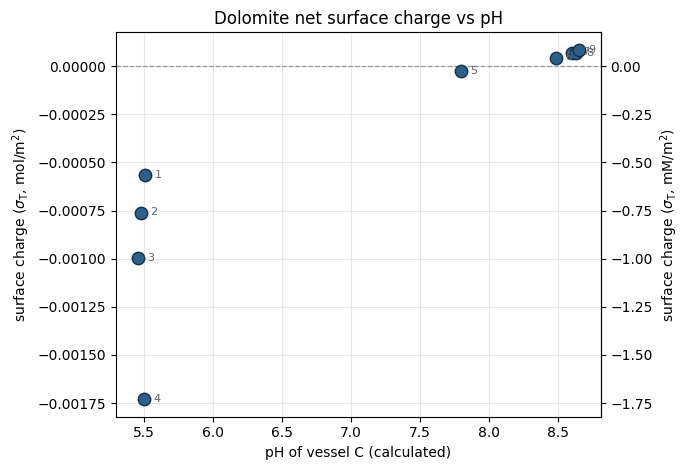

In [25]:
sig = surf['sigma_T (mol/m2)']
fig, ax = plt.subplots(figsize=(7.0,4.8))
ax.axhline(0, color='0.6', lw=0.9, ls='--')
ax.scatter(surf['pH_C'], sig, s=80, color='#2c5f8a', edgecolor='#12314a', zorder=3)
for run, x, y in zip(surf.index, surf['pH_C'], sig):
    ax.annotate(str(run), (x, y), textcoords='offset points', xytext=(7,-2), fontsize=8, color='#666')
ax.set_xlabel('pH of vessel C (calculated)')
ax.set_ylabel(r'surface charge ($\sigma_\mathrm{T}$, mol/m$^2$)')
secax = ax.secondary_yaxis('right', functions=(lambda v: v*1e3, lambda v: v/1e3))
secax.set_ylabel(r'surface charge ($\sigma_\mathrm{T}$, mM/m$^2$)')   # = mmol/m2
ax.set_title('Dolomite net surface charge vs pH')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('surface_charge_vs_pH.png', dpi=150); plt.show()